<a href="https://colab.research.google.com/github/amiraatbk/Neural-network-kntu-/blob/Avang/Avang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simple Inverted Pendulum Neural Network Controller
Generating training data...
Data scaled successfully
Training samples: 16000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training neural network...
Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.4085 - mae: 0.4827 - val_loss: 0.0287 - val_mae: 0.1372
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0179 - mae: 0.1039 - val_loss: 0.0034 - val_mae: 0.0416
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0029 - mae: 0.0388 - val_loss: 0.0025 - val_mae: 0.0365
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0024 - mae: 0.0356 - val_loss: 0.0023 - val_mae: 0.0350
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0022 - mae: 0.0345 - val_loss: 0.0021 - val_mae: 0.0329
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0020 - mae: 0.0329 - val_loss: 0.0020 - val_mae: 0.0325
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0020 - mae: 0.0323 - val_loss: 0.0019 - val_mae: 0.0319
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0019 - mae: 0.0316 - val_loss: 0.0018 - val_mae: 0.0316
Epoch 9/100
500/500 

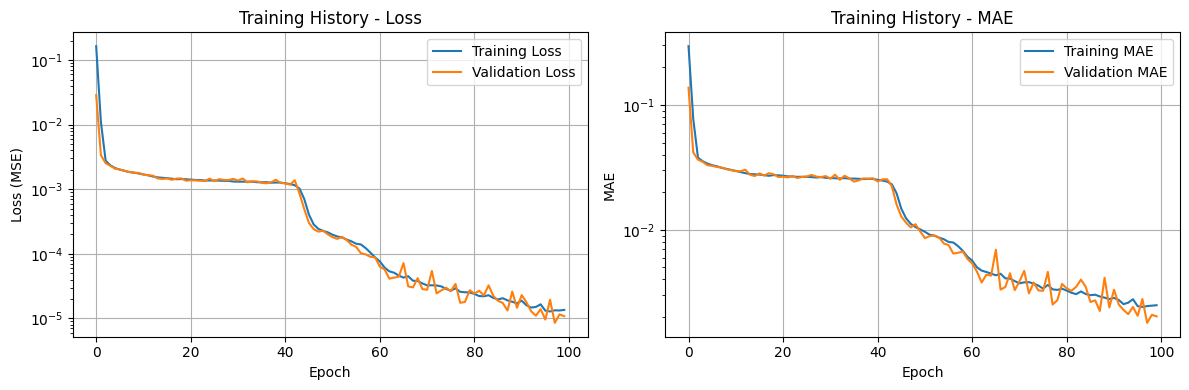

Running simulation...


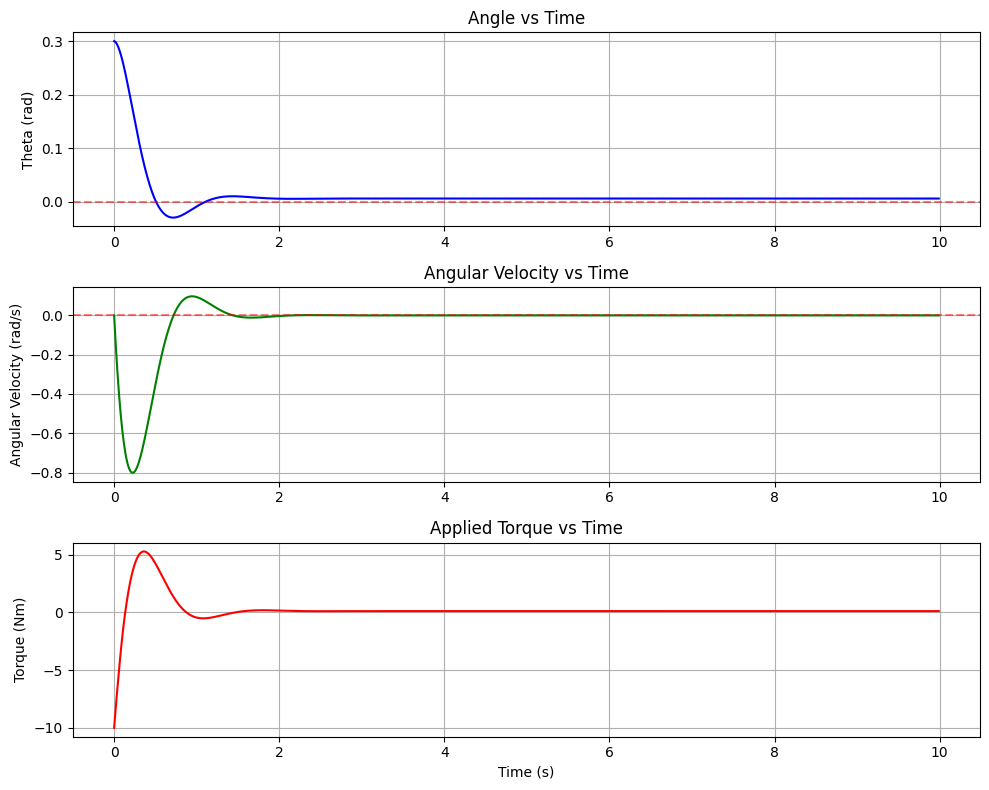


Performance Analysis:
Mean final angle: 0.005723 ± 0.000000 rad
Mean final angular velocity: -0.000000 rad/s
✅ Excellent stabilization!
Model saved as 'simple_pendulum_controller.h5'


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# پارامترهای سیستم
m = 2.0  # kg
R = 1.0  # m
g = 9.81  # m/s²

# تولید داده‌های آموزشی با مقیاس‌بندی مناسب
def generate_training_data(n_samples=30000):
    print("Generating training data...")

    # تولید حالت‌های حول نقطه تعادل
    theta = np.random.uniform(low=-0.5, high=0.5, size=n_samples)
    theta_dot = np.random.uniform(low=-1.0, high=1.0, size=n_samples)

    X = np.column_stack((theta, theta_dot))

    # محاسبه گشتاور ایده‌آل ساده‌تر
    K1 = 100.0  # ضریب برای زاویه
    K2 = 20.0   # ضریب برای سرعت زاویه‌ای

    # گشتاور کنترل + جبران گرانش
    Y = -K1 * theta - K2 * theta_dot - m * g * R * np.sin(theta)

    # محدود کردن گشتاور برای پایداری
    Y = np.clip(Y, -15.0, 15.0)

    return X, Y

# ساخت مدل شبکه عصبی ساده‌تر و پایدارتر
def build_model():
    model = keras.Sequential([
        keras.layers.Dense(32, activation='tanh', input_shape=(2,),
                          kernel_initializer='glorot_uniform'),
        keras.layers.Dense(16, activation='tanh',
                          kernel_initializer='glorot_uniform'),
        keras.layers.Dense(8, activation='tanh',
                          kernel_initializer='glorot_uniform'),
        keras.layers.Dense(1, kernel_initializer='glorot_uniform')
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0005,  # نرخ یادگیری کوچک‌تر
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-8
    )

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

# مقیاس‌بندی داده‌ها
def scale_data(X_train, X_val, Y_train, Y_val):
    # مقیاس‌بندی ویژگی‌های ورودی
    X_scaler = StandardScaler()
    X_train_scaled = X_scaler.fit_transform(X_train)
    X_val_scaled = X_scaler.transform(X_val)

    # مقیاس‌بندی هدف
    Y_scaler = StandardScaler()
    Y_train_scaled = Y_scaler.fit_transform(Y_train.reshape(-1, 1)).flatten()
    Y_val_scaled = Y_scaler.transform(Y_val.reshape(-1, 1)).flatten()

    return X_train_scaled, X_val_scaled, Y_train_scaled, Y_val_scaled, Y_scaler

# شبیه‌سازی سیستم
def simulate_pendulum(model, Y_scaler, initial_theta=0.3, simulation_time=10.0):
    print("Running simulation...")

    dt = 0.01
    n_steps = int(simulation_time / dt)

    theta = initial_theta
    theta_dot = 0.0

    time_points = np.zeros(n_steps)
    theta_history = np.zeros(n_steps)
    theta_dot_history = np.zeros(n_steps)
    torque_history = np.zeros(n_steps)

    for i in range(n_steps):
        time_points[i] = i * dt
        theta_history[i] = theta
        theta_dot_history[i] = theta_dot

        # آماده‌سازی ورودی
        state = np.array([[theta, theta_dot]])

        # پیش‌بینی گشتاور
        M_scaled = model.predict(state, verbose=0)[0, 0]

        # بازگرداندن به مقیاس اصلی
        M = Y_scaler.inverse_transform([[M_scaled]])[0, 0]

        # محدود کردن گشتاور
        M = np.clip(M, -20.0, 20.0)
        torque_history[i] = M

        # معادلات دینامیک
        gravity_torque = m * g * R * np.sin(theta)
        theta_ddot = (M - gravity_torque) / (m * R**2)

        # انتگرال‌گیری
        theta_dot += theta_ddot * dt
        theta += theta_dot * dt

        # محدود کردن مقادیر
        theta = np.clip(theta, -1.5, 1.5)
        theta_dot = np.clip(theta_dot, -3.0, 3.0)

    return time_points, theta_history, theta_dot_history, torque_history

# رسم نتایج
def plot_results(time, theta, theta_dot, torque):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))

    ax1.plot(time, theta, 'b-')
    ax1.set_ylabel('Theta (rad)')
    ax1.set_title('Angle vs Time')
    ax1.grid(True)
    ax1.axhline(0, color='r', linestyle='--', alpha=0.5)

    ax2.plot(time, theta_dot, 'g-')
    ax2.set_ylabel('Angular Velocity (rad/s)')
    ax2.set_title('Angular Velocity vs Time')
    ax2.grid(True)
    ax2.axhline(0, color='r', linestyle='--', alpha=0.5)

    ax3.plot(time, torque, 'r-')
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Torque (Nm)')
    ax3.set_title('Applied Torque vs Time')
    ax3.grid(True)

    plt.tight_layout()
    plt.show()

# تحلیل عملکرد
def analyze_performance(theta, theta_dot):
    # تحلیل 2 ثانیه آخر
    last_indices = int(2.0 / 0.01)
    if len(theta) > last_indices:
        final_theta = theta[-last_indices:]
        final_theta_dot = theta_dot[-last_indices:]
    else:
        final_theta = theta
        final_theta_dot = theta_dot

    mean_theta = np.mean(final_theta)
    std_theta = np.std(final_theta)
    mean_theta_dot = np.mean(final_theta_dot)

    print(f"\nPerformance Analysis:")
    print(f"Mean final angle: {mean_theta:.6f} ± {std_theta:.6f} rad")
    print(f"Mean final angular velocity: {mean_theta_dot:.6f} rad/s")

    if abs(mean_theta) < 0.02 and abs(mean_theta_dot) < 0.05:
        print("✅ Excellent stabilization!")
    elif abs(mean_theta) < 0.05 and abs(mean_theta_dot) < 0.1:
        print("✅ Good stabilization")
    else:
        print("❌ Needs improvement")

# تابع اصلی
def main():
    print("Simple Inverted Pendulum Neural Network Controller")
    print("=" * 50)

    # تولید داده‌ها
    X, Y = generate_training_data(20000)

    # تقسیم داده‌ها
    X_train, X_val, Y_train, Y_val = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    # مقیاس‌بندی داده‌ها
    X_train_scaled, X_val_scaled, Y_train_scaled, Y_val_scaled, Y_scaler = scale_data(
        X_train, X_val, Y_train, Y_val
    )

    print(f"Data scaled successfully")
    print(f"Training samples: {X_train.shape[0]}")

    # ساخت مدل
    model = build_model()

    # آموزش با monitoring
    print("\nTraining neural network...")
    history = model.fit(
        X_train_scaled, Y_train_scaled,
        epochs=100,
        batch_size=32,
        validation_data=(X_val_scaled, Y_val_scaled),
        verbose=1,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            )
        ]
    )

    # نمایش تاریخچه آموزش
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Training History - Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.title('Training History - MAE')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # تست مدل
    time, theta, theta_dot, torque = simulate_pendulum(
        model, Y_scaler, initial_theta=0.3
    )

    # نمایش نتایج
    plot_results(time, theta, theta_dot, torque)

    # تحلیل عملکرد
    analyze_performance(theta, theta_dot)

    # ذخیره مدل
    model.save('simple_pendulum_controller.h5')
    print("Model saved as 'simple_pendulum_controller.h5'")

if __name__ == "__main__":
    main()

Neural Network Controller for 30° Pendulum Angle
Generating training data for target angle: 30.0°
Training samples: 32000

Training neural network for 30° stabilization...
Epoch 1/120


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2978 - mae: 0.3127 - val_loss: 0.0192 - val_mae: 0.1057
Epoch 2/120
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0166 - mae: 0.0996 - val_loss: 0.0104 - val_mae: 0.0813
Epoch 3/120
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0072 - mae: 0.0644 - val_loss: 0.0021 - val_mae: 0.0346
Epoch 4/120
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0017 - mae: 0.0307 - val_loss: 8.8259e-04 - val_mae: 0.0220
Epoch 5/120
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.1440e-04 - mae: 0.0189 - val_loss: 5.2202e-04 - val_mae: 0.0135
Epoch 6/120
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.2462e-04 - mae: 0.0130 - val_loss: 3.6092e-04 - val_mae: 0.0119
Epoch 7/120
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.1077e-04 - mae: 0.0112 - val_loss: 2.7960e-04 - val_mae: 0.0108
Epoch 8/120
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.8271e-04 - mae: 0.0109 - val_loss: 2.5514e-04 - val_mae: 0.0104
Epoch 9/120
500/500 ━━━━

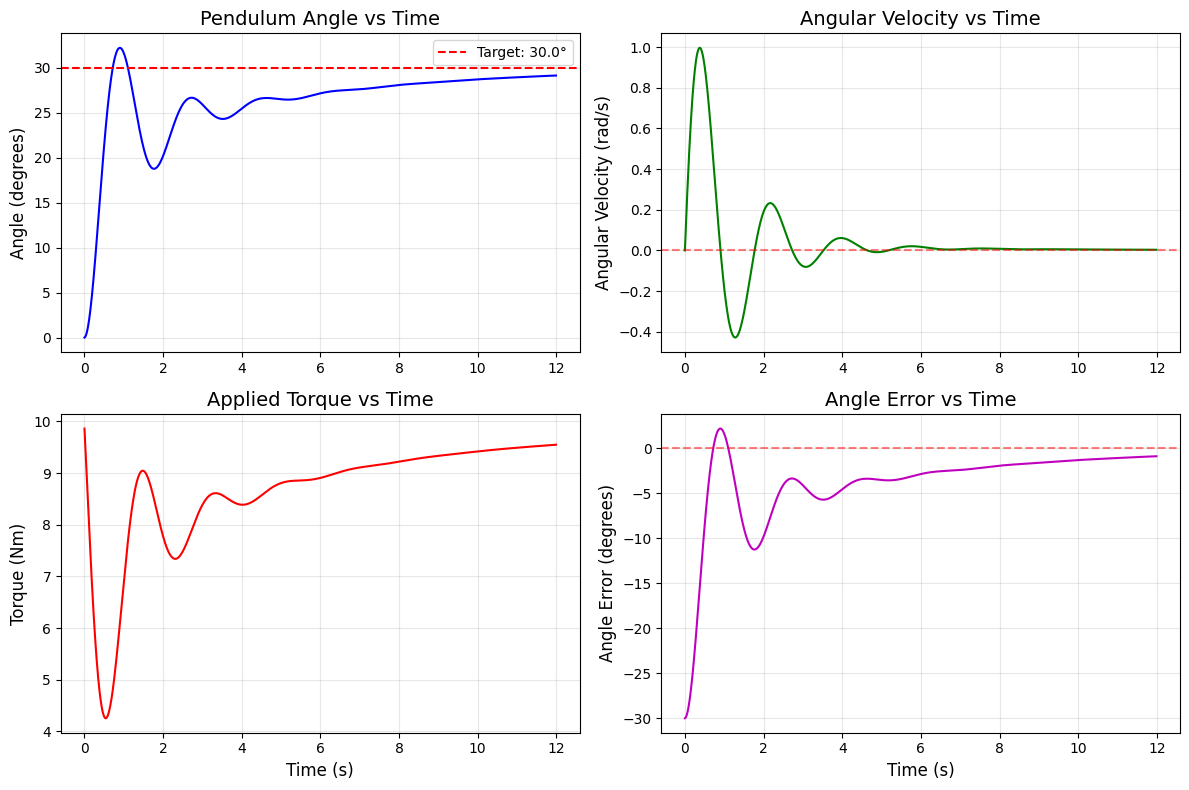


PERFORMANCE ANALYSIS FOR 30.0° TARGET
Mean final angle: 28.804°
Target angle: 30.0°
Angle error: -1.196°
Standard deviation: 0.208°
Mean angular velocity: 0.004252 rad/s
✅ GOOD! Acceptable stabilization at 30°

Testing with initial angle: 28.6°
Simulating for target angle: 30.0°


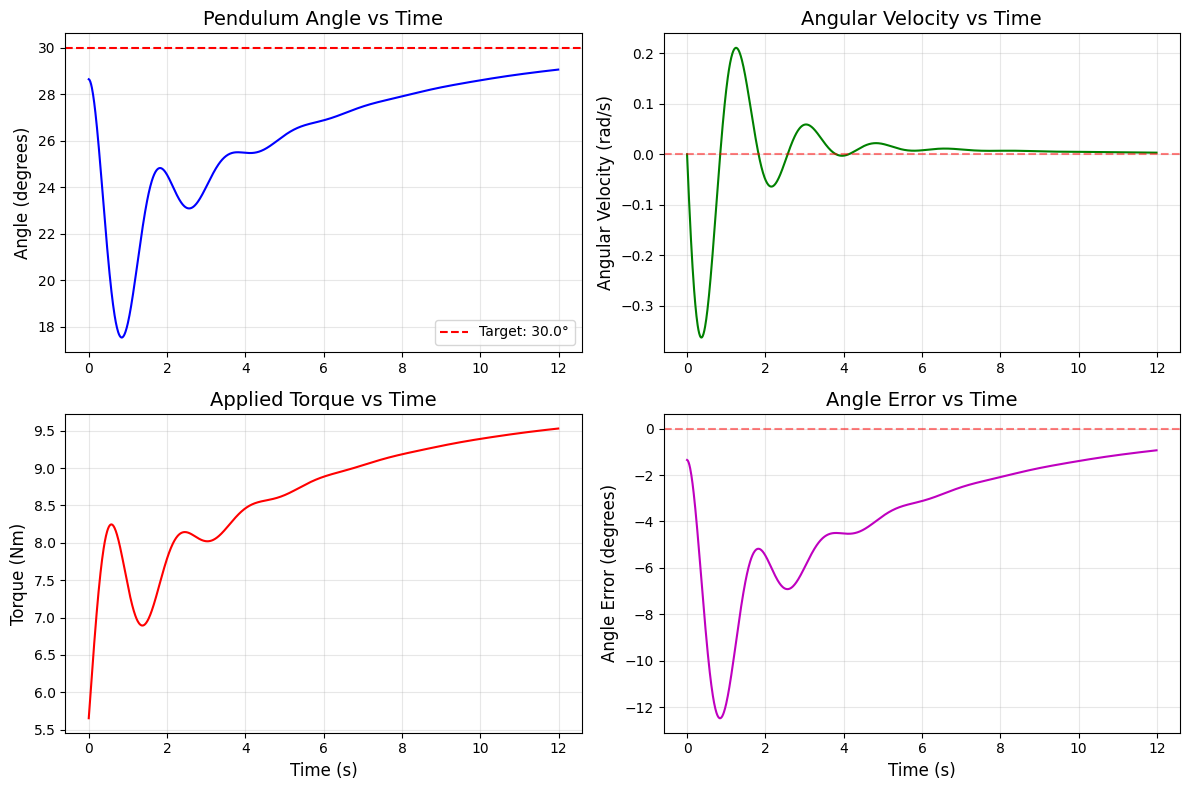


PERFORMANCE ANALYSIS FOR 30.0° TARGET
Mean final angle: 28.717°
Target angle: 30.0°
Angle error: -1.283°
Standard deviation: 0.222°
Mean angular velocity: 0.004468 rad/s
✅ GOOD! Acceptable stabilization at 30°

Testing with initial angle: 57.3°
Simulating for target angle: 30.0°


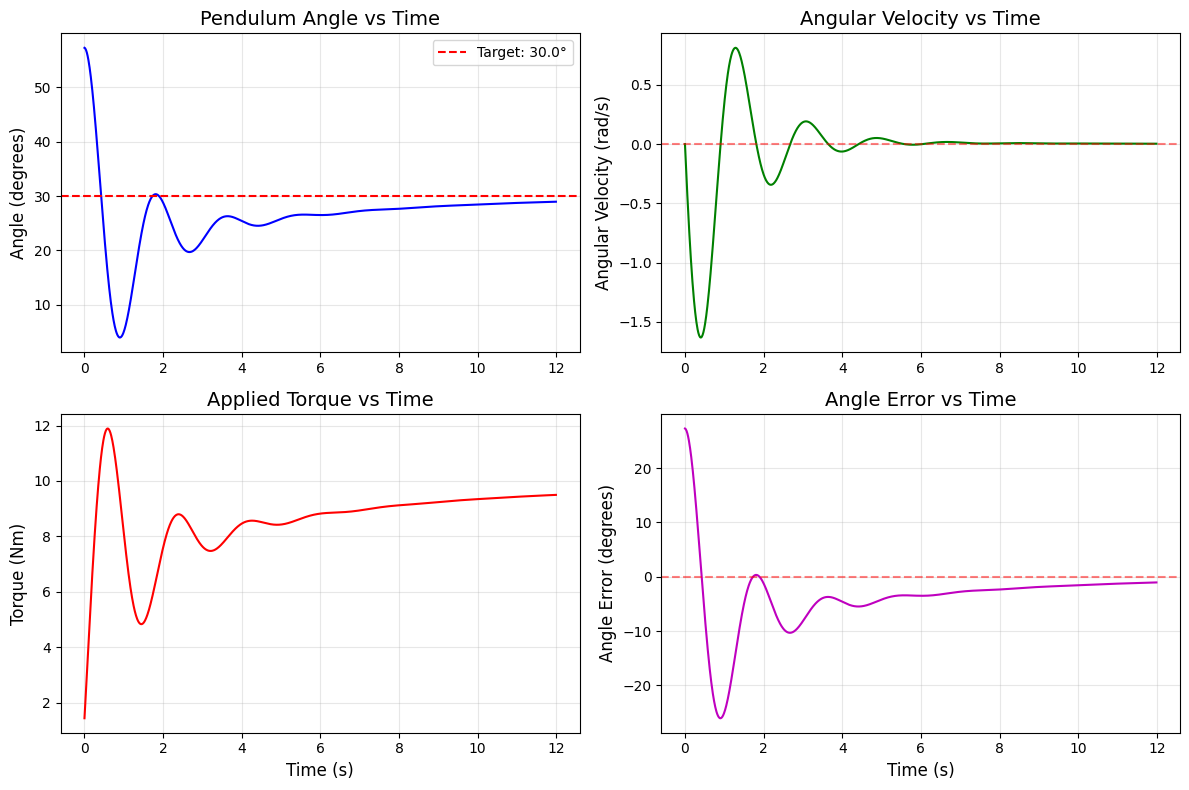


PERFORMANCE ANALYSIS FOR 30.0° TARGET
Mean final angle: 28.581°
Target angle: 30.0°
Angle error: -1.419°
Standard deviation: 0.243°
Mean angular velocity: 0.004857 rad/s
✅ GOOD! Acceptable stabilization at 30°

Model saved as 'pendulum_controller_30deg.h5'


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# پارامترهای سیستم
m = 2.0  # kg
R = 1.0  # m
g = 9.81  # m/s²
target_angle = np.pi / 6  # 30 درجه (π/6 رادیان)

# تولید داده‌های آموزشی برای زاویه 30 درجه
def generate_training_data(n_samples=50000):
    print(f"Generating training data for target angle: {np.degrees(target_angle):.1f}°")

    # تولید داده‌ها حول زاویه هدف 30 درجه
    theta_target_variance = 0.3  # تغییرات حول زاویه هدف
    theta = np.concatenate([
        np.random.uniform(low=target_angle - 0.05, high=target_angle + 0.05, size=int(n_samples * 0.4)),
        np.random.uniform(low=target_angle - 0.1, high=target_angle + 0.1, size=int(n_samples * 0.3)),
        np.random.uniform(low=target_angle - 0.2, high=target_angle + 0.2, size=int(n_samples * 0.2)),
        np.random.uniform(low=target_angle - 0.3, high=target_angle + 0.3, size=int(n_samples * 0.1))
    ])

    theta_dot = np.concatenate([
        np.random.uniform(low=-0.1, high=0.1, size=int(n_samples * 0.5)),
        np.random.uniform(low=-0.3, high=0.3, size=int(n_samples * 0.3)),
        np.random.uniform(low=-0.6, high=0.6, size=int(n_samples * 0.2))
    ])

    np.random.shuffle(theta)
    np.random.shuffle(theta_dot)

    X = np.column_stack((theta, theta_dot))

    # محاسبه گشتاور مورد نیاز برای زاویه 30 درجه
    # در حالت پایدار: M = m*g*R*sin(θ_target)
    gravity_torque_at_target = m * g * R * np.sin(target_angle)

    # کنترلر LQR برای زاویه 30 درجه
    K1 = 100.0  # ضریب برای خطای زاویه
    K2 = 20.0   # ضریب برای سرعت زاویه‌ای

    # خطای زاویه نسبت به هدف 30 درجه
    angle_error = theta - target_angle

    Y = -K1 * angle_error - K2 * theta_dot + gravity_torque_at_target

    # محدود کردن گشتاور
    Y = np.clip(Y, -15.0, 15.0)

    return X, Y

# ساخت مدل شبکه عصبی
def build_model():
    model = keras.Sequential([
        keras.layers.Dense(64, activation='tanh', input_shape=(2,),
                          kernel_initializer='glorot_uniform'),
        keras.layers.Dense(32, activation='tanh',
                          kernel_initializer='glorot_uniform'),
        keras.layers.Dense(16, activation='tanh',
                          kernel_initializer='glorot_uniform'),
        keras.layers.Dense(1, kernel_initializer='glorot_uniform')
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0005,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-8
    )

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

# مقیاس‌بندی داده‌ها
def scale_data(X_train, X_val, Y_train, Y_val):
    X_scaler = StandardScaler()
    X_train_scaled = X_scaler.fit_transform(X_train)
    X_val_scaled = X_scaler.transform(X_val)

    Y_scaler = StandardScaler()
    Y_train_scaled = Y_scaler.fit_transform(Y_train.reshape(-1, 1)).flatten()
    Y_val_scaled = Y_scaler.transform(Y_val.reshape(-1, 1)).flatten()

    return X_train_scaled, X_val_scaled, Y_train_scaled, Y_val_scaled, Y_scaler

# شبیه‌سازی برای زاویه 30 درجه
def simulate_pendulum_30_degrees(model, Y_scaler, initial_theta=0.0, simulation_time=12.0):
    print(f"Simulating for target angle: {np.degrees(target_angle):.1f}°")

    dt = 0.01
    n_steps = int(simulation_time / dt)

    theta = initial_theta
    theta_dot = 0.0
    angle_error_integral = 0.0

    time_points = np.zeros(n_steps)
    theta_history = np.zeros(n_steps)
    theta_dot_history = np.zeros(n_steps)
    torque_history = np.zeros(n_steps)
    angle_error_history = np.zeros(n_steps)

    for i in range(n_steps):
        time_points[i] = i * dt
        theta_history[i] = theta
        theta_dot_history[i] = theta_dot

        # محاسبه خطای زاویه نسبت به هدف 30 درجه
        angle_error = theta - target_angle
        angle_error_history[i] = angle_error
        angle_error_integral += angle_error * dt
        angle_error_integral = np.clip(angle_error_integral, -1.0, 1.0)

        # آماده‌سازی ورودی برای شبکه
        state = np.array([[theta, theta_dot]])

        # پیش‌بینی گشتاور پایه
        M_scaled = model.predict(state, verbose=0)[0, 0]
        M_base = Y_scaler.inverse_transform([[M_scaled]])[0, 0]

        # اضافه کردن ترم انتگرالی برای دقت بیشتر
        M_integral = -5.0 * angle_error_integral
        M_total = M_base + M_integral

        # محدود کردن گشتاور نهایی
        M_total = np.clip(M_total, -18.0, 18.0)
        torque_history[i] = M_total

        # معادلات دینامیک
        gravity_torque = m * g * R * np.sin(theta)
        theta_ddot = (M_total - gravity_torque) / (m * R**2)

        # انتگرال‌گیری
        theta_dot += theta_ddot * dt
        theta += theta_dot * dt

        # محدود کردن مقادیر
        theta = np.clip(theta, -np.pi/2, np.pi/2)
        theta_dot = np.clip(theta_dot, -3.0, 3.0)

    return time_points, theta_history, theta_dot_history, torque_history, angle_error_history

# رسم نتایج برای زاویه 30 درجه
def plot_results_30_degrees(time, theta, theta_dot, torque, angle_error):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

    # نمودار زاویه
    ax1.plot(time, np.degrees(theta), 'b-', linewidth=1.5)
    ax1.axhline(np.degrees(target_angle), color='r', linestyle='--',
                label=f'Target: {np.degrees(target_angle):.1f}°')
    ax1.set_ylabel('Angle (degrees)', fontsize=12)
    ax1.set_title('Pendulum Angle vs Time', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # نمودار سرعت زاویه‌ای
    ax2.plot(time, theta_dot, 'g-', linewidth=1.5)
    ax2.set_ylabel('Angular Velocity (rad/s)', fontsize=12)
    ax2.set_title('Angular Velocity vs Time', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(0, color='r', linestyle='--', alpha=0.5)

    # نمودار گشتاور
    ax3.plot(time, torque, 'r-', linewidth=1.5)
    ax3.set_xlabel('Time (s)', fontsize=12)
    ax3.set_ylabel('Torque (Nm)', fontsize=12)
    ax3.set_title('Applied Torque vs Time', fontsize=14)
    ax3.grid(True, alpha=0.3)

    # نمودار خطای زاویه
    ax4.plot(time, np.degrees(angle_error), 'm-', linewidth=1.5)
    ax4.set_xlabel('Time (s)', fontsize=12)
    ax4.set_ylabel('Angle Error (degrees)', fontsize=12)
    ax4.set_title('Angle Error vs Time', fontsize=14)
    ax4.grid(True, alpha=0.3)
    ax4.axhline(0, color='r', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# تحلیل عملکرد برای زاویه 30 درجه
def analyze_performance_30_degrees(theta, theta_dot, angle_error, time):
    # تحلیل 3 ثانیه آخر
    last_indices = int(3.0 / 0.01)
    if len(theta) > last_indices:
        final_theta = theta[-last_indices:]
        final_theta_dot = theta_dot[-last_indices:]
        final_error = angle_error[-last_indices:]
    else:
        final_theta = theta
        final_theta_dot = theta_dot
        final_error = angle_error

    mean_theta = np.mean(final_theta)
    mean_degrees = np.degrees(mean_theta)
    std_theta = np.std(final_theta)
    mean_error = np.mean(final_error)
    mean_error_degrees = np.degrees(mean_error)

    print("\n" + "="*60)
    print(f"PERFORMANCE ANALYSIS FOR {np.degrees(target_angle):.1f}° TARGET")
    print("="*60)
    print(f"Mean final angle: {mean_degrees:.3f}°")
    print(f"Target angle: {np.degrees(target_angle):.1f}°")
    print(f"Angle error: {mean_error_degrees:.3f}°")
    print(f"Standard deviation: {np.degrees(std_theta):.3f}°")
    print(f"Mean angular velocity: {np.mean(final_theta_dot):.6f} rad/s")

    # معیارهای ارزیابی
    if abs(mean_error_degrees) < 0.5 and np.degrees(std_theta) < 0.3:
        print("🎯 EXCELLENT! Perfect stabilization at 30°!")
    elif abs(mean_error_degrees) < 1.0 and np.degrees(std_theta) < 0.5:
        print("✅ VERY GOOD! Excellent stabilization at 30°!")
    elif abs(mean_error_degrees) < 2.0:
        print("✅ GOOD! Acceptable stabilization at 30°")
    else:
        print("⚠️  Needs improvement")

# تابع اصلی
def main():
    print("Neural Network Controller for 30° Pendulum Angle")
    print("=" * 55)

    # تولید داده‌های آموزشی
    X, Y = generate_training_data(40000)

    # تقسیم داده‌ها
    X_train, X_val, Y_train, Y_val = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    # مقیاس‌بندی
    X_train_scaled, X_val_scaled, Y_train_scaled, Y_val_scaled, Y_scaler = scale_data(
        X_train, X_val, Y_train, Y_val
    )

    print(f"Training samples: {X_train.shape[0]}")

    # ساخت و آموزش مدل
    model = build_model()

    print("\nTraining neural network for 30° stabilization...")
    history = model.fit(
        X_train_scaled, Y_train_scaled,
        epochs=120,
        batch_size=64,
        validation_data=(X_val_scaled, Y_val_scaled),
        verbose=1,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=12,
                restore_best_weights=True
            )
        ]
    )

    # شبیه‌سازی از حالت اولیه مختلف
    initial_angles = [0.0, 0.5, 1.0]  # رادیان

    for init_angle in initial_angles:
        print(f"\nTesting with initial angle: {np.degrees(init_angle):.1f}°")
        time, theta, theta_dot, torque, angle_error = simulate_pendulum_30_degrees(
            model, Y_scaler, initial_theta=init_angle
        )

        # نمایش نتایج
        plot_results_30_degrees(time, theta, theta_dot, torque, angle_error)

        # تحلیل عملکرد
        analyze_performance_30_degrees(theta, theta_dot, angle_error, time)

    # ذخیره مدل
    model.save(f'pendulum_controller_{np.degrees(target_angle):.0f}deg.h5')
    print(f"\nModel saved as 'pendulum_controller_{np.degrees(target_angle):.0f}deg.h5'")

if __name__ == "__main__":
    main()